In [4]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

In [5]:
data_path = "E:\\src\\neat-calculator\\data_collection\\recordings\\sensor_data\\1767099292263.json"

data = pd.read_json(data_path)

In [6]:
data.head()

,accelerometerX,accelerometerY,accelerometerZ,gyroscopeX,gyroscopeY,gyroscopeZ,timestamp,timestampNanos
0,-0.16,3.60,9.16,-0.01,-0.02,0.01,2025-12-30 12:54:52.489,1974-07-01 19:14:51.244808
1,-0.16,3.60,9.16,-0.02,-0.01,0.01,2025-12-30 12:54:52.492,1974-07-01 19:14:55.429600
2,-0.14,3.63,9.15,-0.02,-0.01,0.01,2025-12-30 12:54:52.498,1974-07-01 19:15:01.245173
3,-0.14,3.63,9.15,-0.02,0.00,0.00,2025-12-30 12:54:52.503,1974-07-01 19:15:05.552933
4,-0.13,3.61,9.02,-0.02,0.00,0.00,2025-12-30 12:54:52.510,1974-07-01 19:15:12.872985


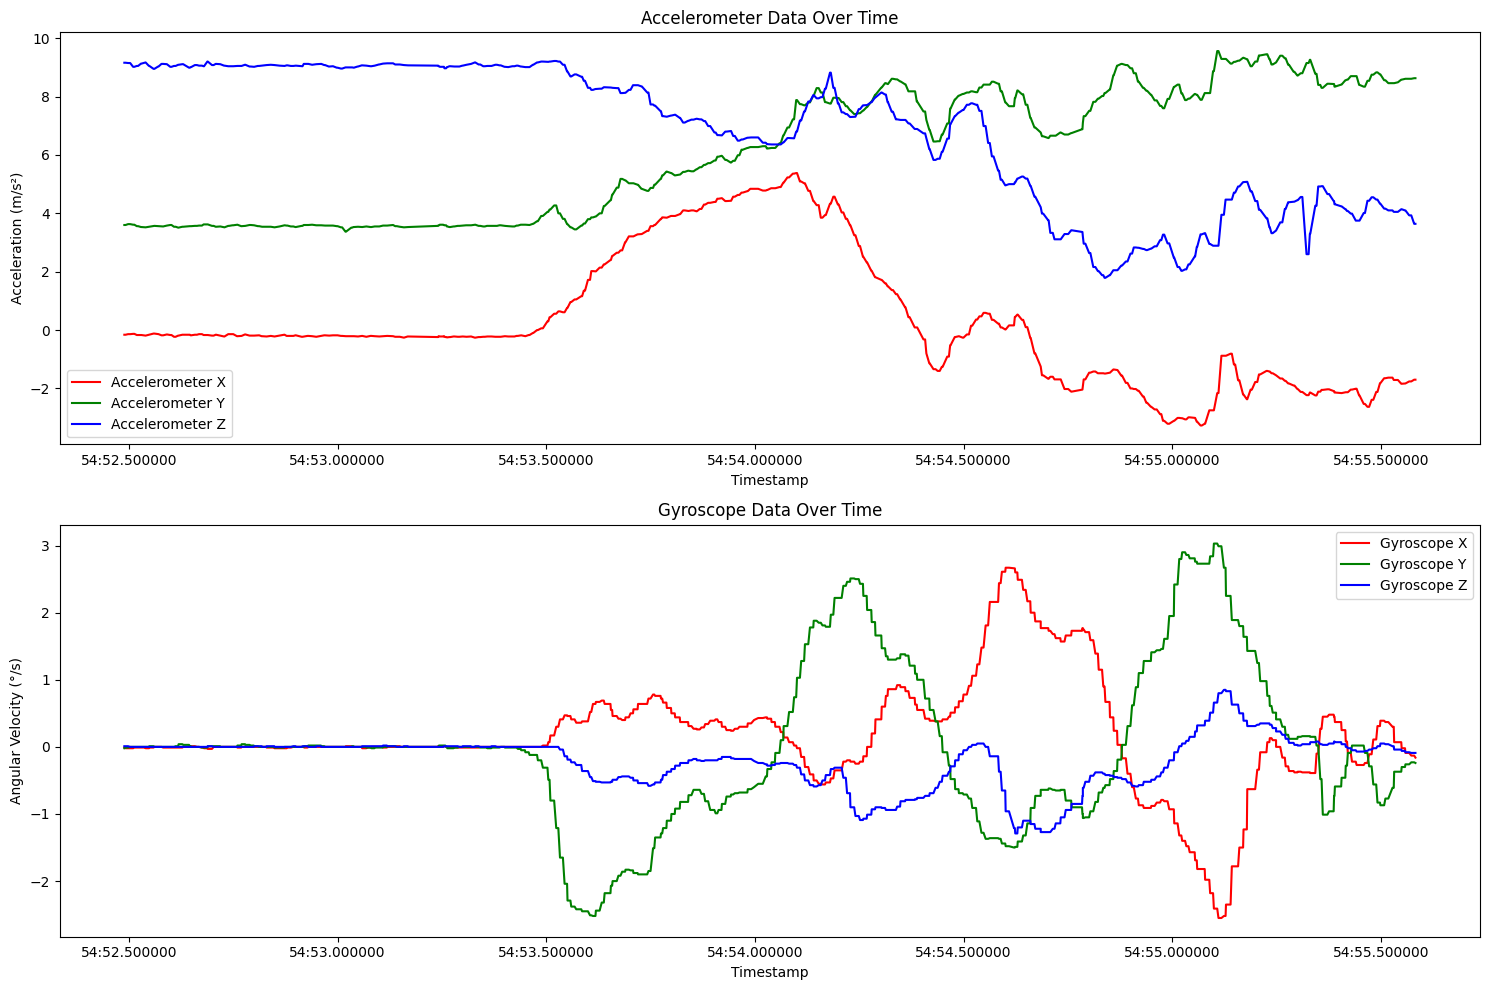

In [8]:
plt.figure(figsize=(15, 10))
plt.subplot(2, 1, 1)
plt.plot(data['timestamp'], data['accelerometerX'], label='Accelerometer X', color='r')
plt.plot(data['timestamp'], data['accelerometerY'], label='Accelerometer Y', color='g')
plt.plot(data['timestamp'], data['accelerometerZ'], label='Accelerometer Z', color='b')
plt.title('Accelerometer Data Over Time')

plt.xlabel('Timestamp')
plt.ylabel('Acceleration (m/s²)')
plt.legend()
plt.subplot(2, 1, 2)
plt.plot(data['timestamp'], data['gyroscopeX'], label='Gyroscope X', color='r')
plt.plot(data['timestamp'], data['gyroscopeY'], label='Gyroscope Y', color='g')
plt.plot(data['timestamp'], data['gyroscopeZ'], label='Gyroscope Z', color='b')
plt.title('Gyroscope Data Over Time')

plt.xlabel('Timestamp')
plt.ylabel('Angular Velocity (°/s)')
plt.legend()
plt.tight_layout()
plt.show()

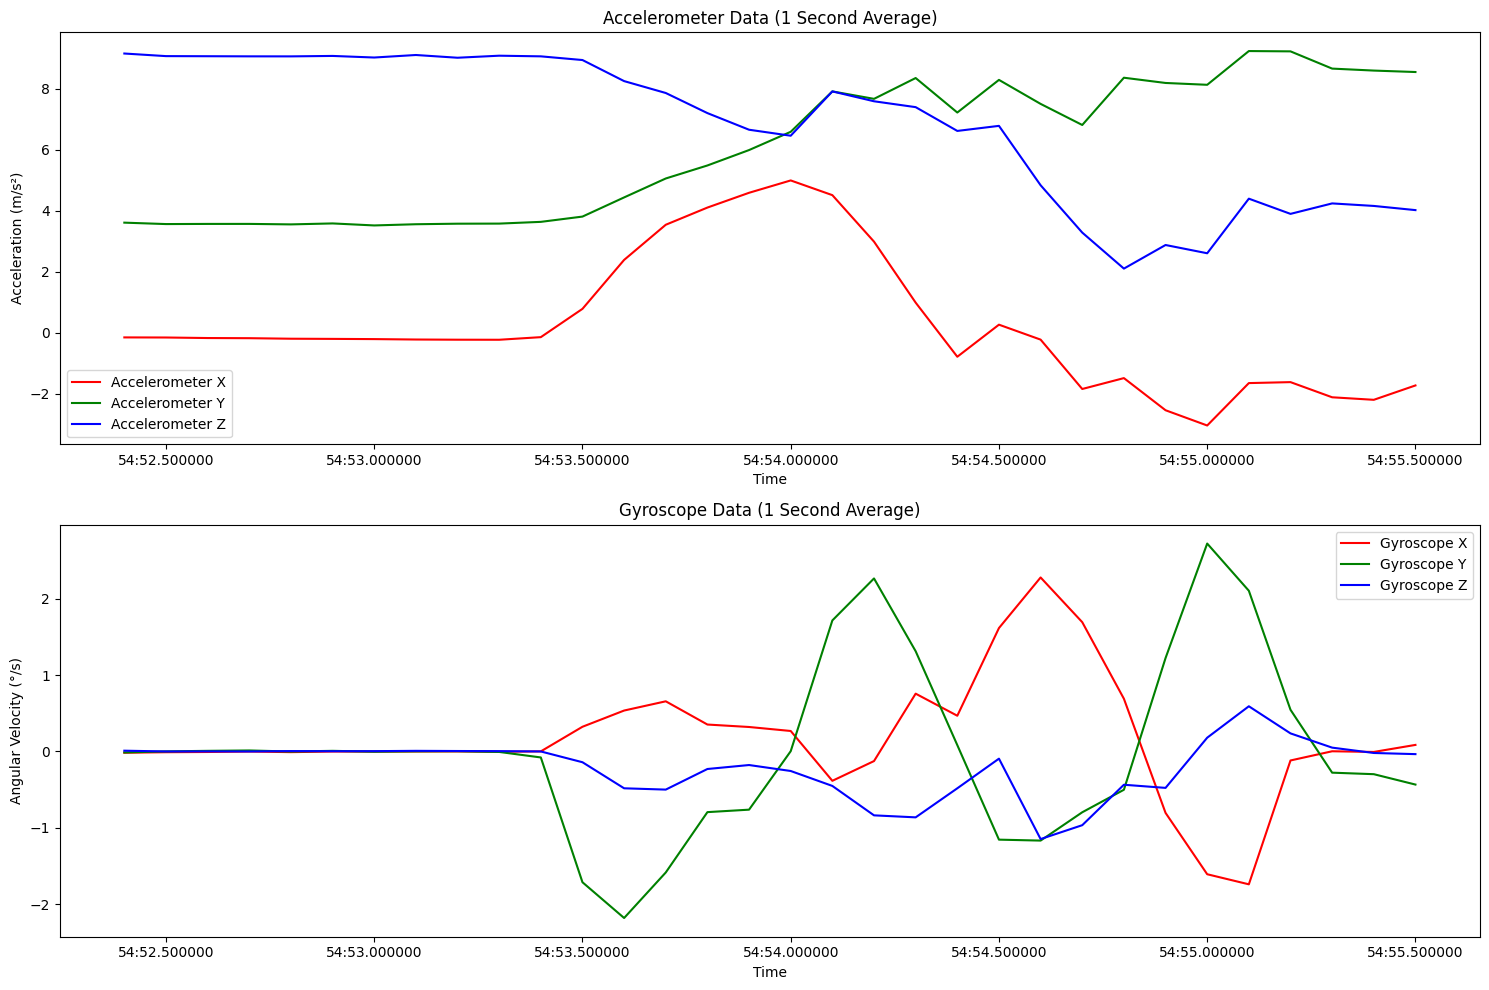

In [10]:
# Convert timestamp to datetime and set as index
data['datetime'] = pd.to_datetime(data['timestamp'], unit='ms')
data_resampled = data.set_index('datetime').resample('100ms').mean()

# Plot resampled data
plt.figure(figsize=(15, 10))
plt.subplot(2, 1, 1)
plt.plot(data_resampled.index, data_resampled['accelerometerX'], label='Accelerometer X', color='r')
plt.plot(data_resampled.index, data_resampled['accelerometerY'], label='Accelerometer Y', color='g')
plt.plot(data_resampled.index, data_resampled['accelerometerZ'], label='Accelerometer Z', color='b')
plt.title('Accelerometer Data (1 Second Average)')
plt.xlabel('Time')
plt.ylabel('Acceleration (m/s²)')
plt.legend()

plt.subplot(2, 1, 2)
plt.plot(data_resampled.index, data_resampled['gyroscopeX'], label='Gyroscope X', color='r')
plt.plot(data_resampled.index, data_resampled['gyroscopeY'], label='Gyroscope Y', color='g')
plt.plot(data_resampled.index, data_resampled['gyroscopeZ'], label='Gyroscope Z', color='b')
plt.title('Gyroscope Data (1 Second Average)')
plt.xlabel('Time')
plt.ylabel('Angular Velocity (°/s)')
plt.legend()
plt.tight_layout()
plt.show()